In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [20]:
print("=== STAGE 1: DATA LOAD HO RAHA HAI ===")
df = pd.read_csv('Agriculture_price_dataset.csv')
print(f"Dataset Loaded! Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")

=== STAGE 1: DATA LOAD HO RAHA HAI ===
Dataset Loaded! Total Rows: 737392, Total Columns: 10



In [21]:
df.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [22]:
print("\n* Missing Values Check:")
print(df.isnull().sum())


* Missing Values Check:
STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64


In [23]:
print("\n* Top 5 States jahan ka sabse zyada data hai:")
print(df['STATE'].value_counts().head())

print("\n* Top 5 Commodities (Sabse zyada bikne wali faslein):")
print(df['Commodity'].value_counts().head())


* Top 5 States jahan ka sabse zyada data hai:
STATE
Uttar Pradesh     188094
Tamilnadu          66602
Haryana            63222
Madhya Pradesh     55901
West Bengal        53927
Name: count, dtype: int64

* Top 5 Commodities (Sabse zyada bikne wali faslein):
Commodity
Potato    327332
Onion     298658
Wheat      76976
Tomato     26644
Rice        7782
Name: count, dtype: int64


Text(0, 0.5, 'Count')

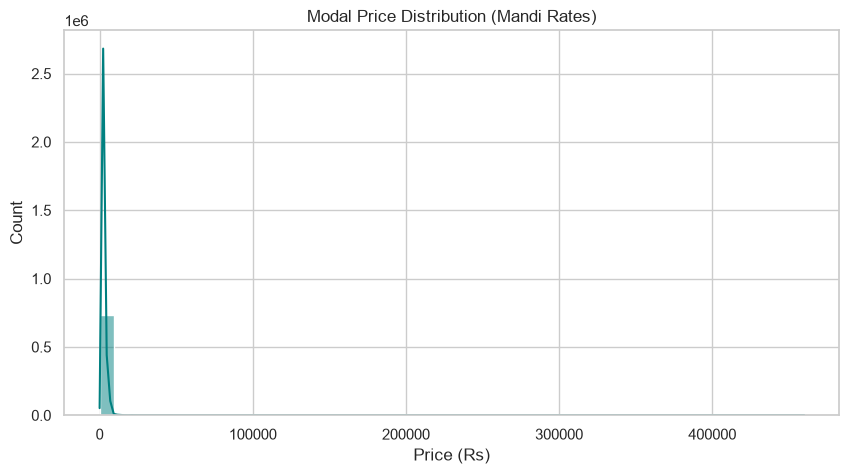

In [24]:

sns.set_theme(style="whitegrid")

# Graph 1: Modal Price ka Distribution (Mandi rates ka failav)
plt.figure(figsize=(10, 5))
sns.histplot(df['Modal_Price'], kde=True, bins=50, color='teal')
plt.title('Modal Price Distribution (Mandi Rates)')
plt.xlabel('Price (Rs)')
plt.ylabel('Count')



Text(0.5, 1.0, 'Price Correlation Heatmap')

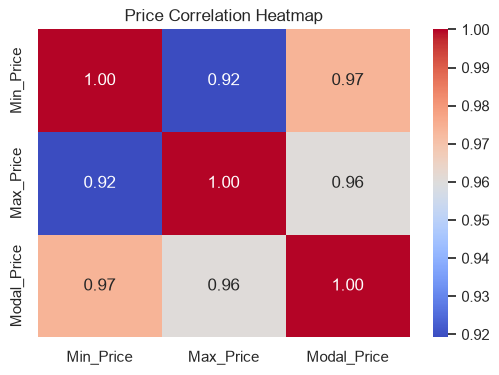

In [25]:
plt.figure(figsize=(6, 4))
numeric_cols = ['Min_Price', 'Max_Price', 'Modal_Price']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Price Correlation Heatmap')


In [26]:

df['Price Date'] = pd.to_datetime(df['Price Date'], errors='coerce')
df['Year'] = df['Price Date'].dt.year
df['Month'] = df['Price Date'].dt.month
df.drop('Price Date', axis=1, inplace=True)
df.dropna(inplace=True)

In [27]:
categorical_cols = ['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("-> Cleaning aur Label Encoding done.\n")

-> Cleaning aur Label Encoding poori ho gayi hai.



In [28]:
X = df.drop(['Min_Price', 'Max_Price', 'Modal_Price' , 'Grade'], axis=1)
y = df['Modal_Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train Data Size: {X_train.shape[0]} rows, Test Data Size: {X_test.shape[0]} rows\n")

Train Data Size: 589913 rows, Test Data Size: 147479 rows



In [29]:
print("=== STAGE 5: MODEL TRAINING  ===")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


=== STAGE 5: MODEL TRAINING  ===
-> Model train ho chuka hai!



In [30]:
print("=== STAGE 6: MODEL PERFORMANCE ===")
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print(f"Mean Absolute Error : {mae:.2f} Rs")
print(f"R2 Score (Accuracy): {r2:.2f} (Yaani {r2*100:.1f}%)")
print("=" * 50)

=== STAGE 6: MODEL PERFORMANCE ===
Mean Absolute Error : 212.98 Rs
R2 Score (Accuracy): 0.81 (Yaani 81.0%)
